# Sensorium video → (60×80): resize strategies

The CNN expects **(H, W) = (60, 80)**. Raw Sensorium trial videos are **`(N_frames, H, W)`** (e.g. **64×324**). `SensoriumDataset` does:

1. **`resize_video_frame`** (anisotropic `zoom` to 60×80)
2. **`normalize_movie`** (min–max on **that 60×80** image)
3. `nan_to_num` + clip to [0, 1]

So **contrast is computed after resize**, not on the native frame. An earlier version of this notebook normalized **before** resize for some panels; that **does not** match training. The cells below fix that and add a **true raw** view (no min–max) for sanity checks.

**Panels:**
- **As loaded** — raw floats from `videos/{trial}.npy` (shared `vmin`/`vmax` per frame for display).
- **Native min–max** — `normalize_movie` on the **full** H×W (for shape-only comparison; *not* what the CNN sees).
- **`dataset (resize→norm)`** — matches `SensoriumDataset` exactly for the stretch path.
- Other methods resize on **raw** luminance, then apply the same **resize→norm** tail as the dataset on the 60×80 result.


In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# Same resize + normalize order as training (single source of truth)
from mouse_model.sensorium_dataset import resize_video_frame, normalize_movie

# --- paths ---
SENSORIUM_ROOT = os.path.expanduser(
    "/home/herbelinluke/Downloads/dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20"
)
TRIAL_ID = 4
FRAME_INDICES = [0, 9, 17, 26, 35]  # across a 36-frame trial

TARGET_HW = (60, 80)  # H, W — matches VisualEncoderTransfer default input_shape


In [61]:
def finalize_like_dataset(frame_60_80: np.ndarray) -> np.ndarray:
    """Same tail as SensoriumDataset after spatial resize."""
    x = normalize_movie(frame_60_80)
    x = np.nan_to_num(x, nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(x, 0.0, 1.0)


def dataset_stretch_squash(raw_frame: np.ndarray) -> np.ndarray:
    """Exact stretch path: resize_video_frame then normalize (matches SensoriumDataset)."""
    z = resize_video_frame(raw_frame, TARGET_HW)
    return finalize_like_dataset(z)


def wrong_order_normalize_then_zoom(raw_frame: np.ndarray) -> np.ndarray:
    """NOT training: min-max on native H×W, then anisotropic zoom. No second min-max."""
    th, tw = TARGET_HW
    h, w = raw_frame.shape
    z = zoom(normalize_movie(raw_frame.astype(float)), (th / h, tw / w), order=1)
    return np.clip(np.nan_to_num(z, nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0)


def letterbox_raw_then_normalize(raw_frame: np.ndarray, target_hw=(60, 80), fill=0.0) -> np.ndarray:
    """Uniform scale raw frame to fit inside target; pad; then dataset-style normalize on 60×80."""
    th, tw = target_hw
    h, w = raw_frame.shape
    scale = min(th / h, tw / w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))
    z = zoom(raw_frame.astype(float), (new_h / h, new_w / w), order=1)
    out = np.full((th, tw), fill, dtype=np.float64)
    y0 = (th - z.shape[0]) // 2
    x0 = (tw - z.shape[1]) // 2
    out[y0 : y0 + z.shape[0], x0 : x0 + z.shape[1]] = z
    return finalize_like_dataset(out)


def center_crop_raw_then_stretch(raw_frame: np.ndarray, target_hw=(60, 80)) -> np.ndarray:
    """Center crop to target aspect ratio on raw floats, then anisotropic zoom to target_hw."""
    th, tw = target_hw
    ar_tgt = tw / th
    h, w = raw_frame.shape
    ar_src = w / h
    if ar_src > ar_tgt:
        cw = int(round(h * ar_tgt))
        ch = h
        x0 = (w - cw) // 2
        y0 = 0
    else:
        cw = w
        ch = int(round(w / ar_tgt))
        x0 = 0
        y0 = (h - ch) // 2
    cropped = raw_frame[y0 : y0 + ch, x0 : x0 + cw]
    z = zoom(cropped.astype(float), (th / cropped.shape[0], tw / cropped.shape[1]), order=1)
    return finalize_like_dataset(z)


METHODS = {
    "dataset (resize→norm)": dataset_stretch_squash,
    "letterbox (raw→pad→norm)": letterbox_raw_then_normalize,
    "center_crop → 60×80": center_crop_raw_then_stretch,
}


In [62]:
vid_path = os.path.join(SENSORIUM_ROOT, "data", "videos", f"{TRIAL_ID}.npy")
if not os.path.isfile(vid_path):
    raise FileNotFoundError(f"Missing {vid_path} — set SENSORIUM_ROOT.")

raw_vid = np.load(vid_path)
n_frames = raw_vid.shape[0]
print("Loaded:", vid_path)
print("Shape (N_frames, H, W):", raw_vid.shape, "dtype:", raw_vid.dtype)

# Sanity: one frame is (H, W); no accidental axis swap
fi0 = FRAME_INDICES[0]
fr = raw_vid[fi0]
assert fr.ndim == 2, fr.shape
print(f"\nFrame [{fi0}] shape {fr.shape}: min={np.nanmin(fr):.6g} max={np.nanmax(fr):.6g} nan_count={np.isnan(fr).sum()}")

for fi in FRAME_INDICES:
    if fi >= n_frames:
        raise ValueError(f"FRAME_INDICES contains {fi} but video has only {n_frames} frames")


Loaded: /home/herbelinluke/Downloads/dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20/data/videos/4.npy
Shape (N_frames, H, W): (36, 64, 324) dtype: float64

Frame [0] shape (64, 324): min=78.7955 max=220.904 nan_count=1536


In [63]:
def pipeline_for_display(raw_frame: np.ndarray) -> dict:
    """Build visualization dict: true raw, native min-max, then 60×80 methods (dataset order)."""
    out = {}
    # True values from disk (may be arbitrary float range)
    out["as_loaded (raw)"] = raw_frame.astype(np.float64)
    # Full-res min-max — NOT the training pipeline; only for comparing wide FOV appearance
    out["native min-max only"] = np.clip(
        np.nan_to_num(normalize_movie(raw_frame), nan=0.0, posinf=1.0, neginf=0.0), 0.0, 1.0
    )
    for name, fn in METHODS.items():
        out[name] = fn(raw_frame)
    return out


def show_frame_comparison(frame_idx: int):
    raw = raw_vid[frame_idx]
    imgs = pipeline_for_display(raw)
    keys = list(imgs.keys())
    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.8))
    if n == 1:
        axes = [axes]
    h0, w0 = raw.shape
    for ax, k in zip(axes, keys):
        im = imgs[k]
        if k == "as_loaded (raw)":
            vmin, vmax = np.nanmin(im), np.nanmax(im)
            if np.isclose(vmin, vmax):
                vmin, vmax = vmin - 1e-6, vmax + 1e-6
            ax.imshow(im, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(f"{k}\n({h0}×{w0})", fontsize=8)
        elif k == "native min-max only":
            ax.imshow(im, cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{k}\n({h0}×{w0})", fontsize=8)
        else:
            ax.imshow(im, cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{k}\n→ {TARGET_HW[0]}×{TARGET_HW[1]}", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"Trial {TRIAL_ID} — frame {frame_idx}", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


def max_abs_diff_wrong_vs_dataset(raw_frame: np.ndarray) -> float:
    """How much training order vs normalize-first differs for the squash path."""
    right = dataset_stretch_squash(raw_frame)
    wrong = wrong_order_normalize_then_zoom(raw_frame)
    return float(np.nanmax(np.abs(right - wrong)))


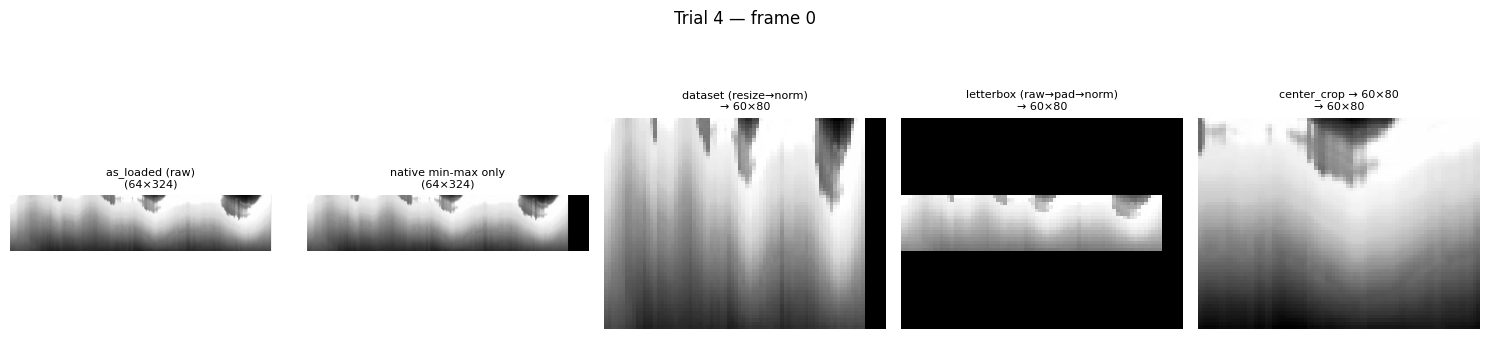

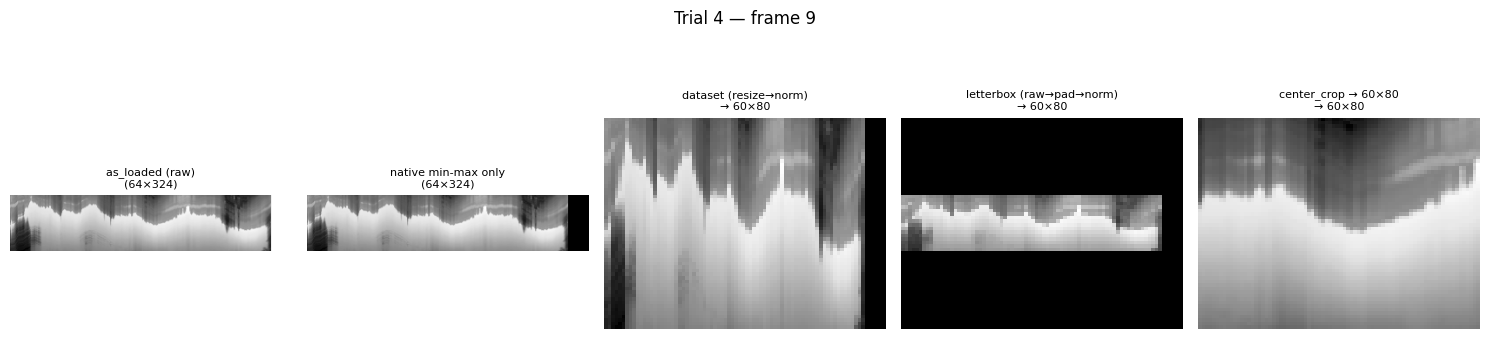

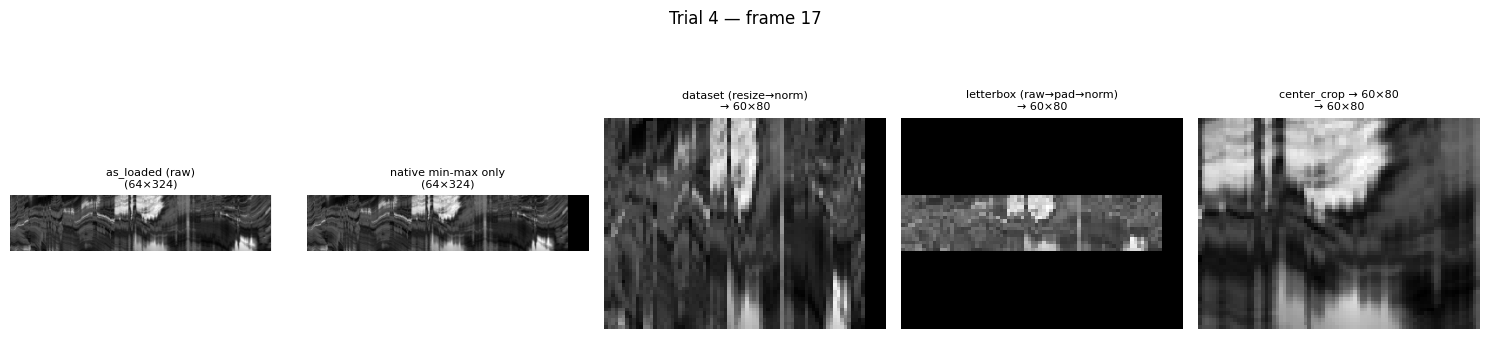

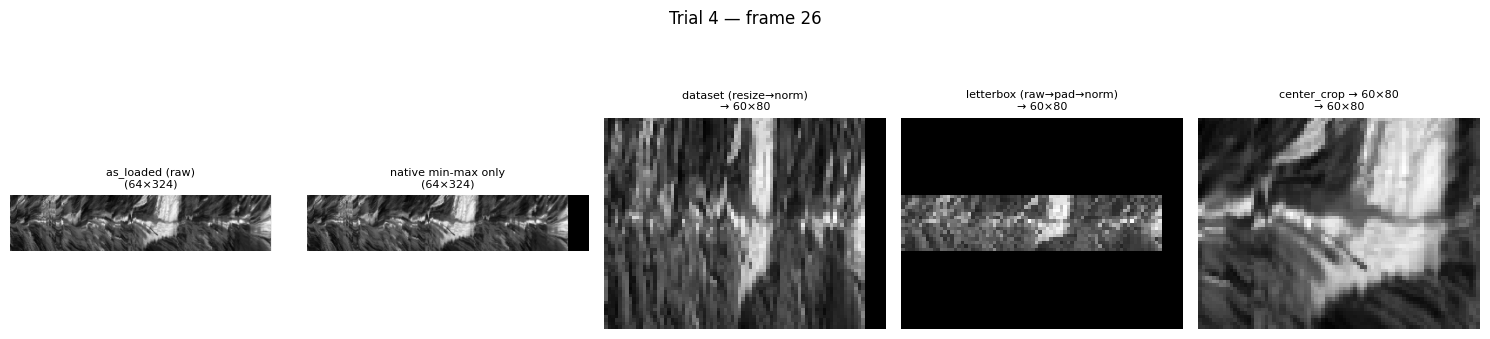

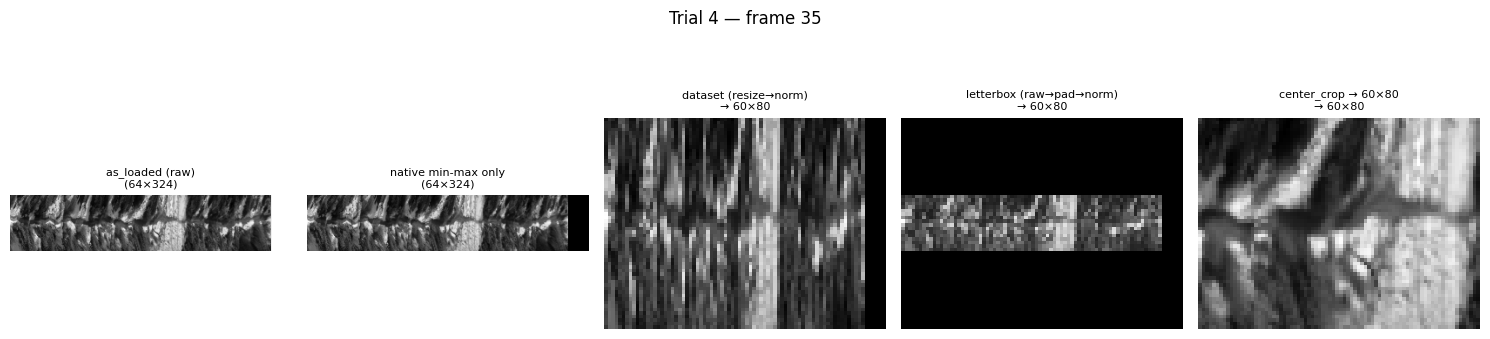

In [64]:
for fi in FRAME_INDICES:
    show_frame_comparison(fi)

## Optional: quantify order mismatch

Training uses **resize → normalize**. If you min-max on the native frame first, the 60×80 image can differ (often noticeably on wide frames).


max |dataset − (normalize then resize)|: 0.0019277303873330679


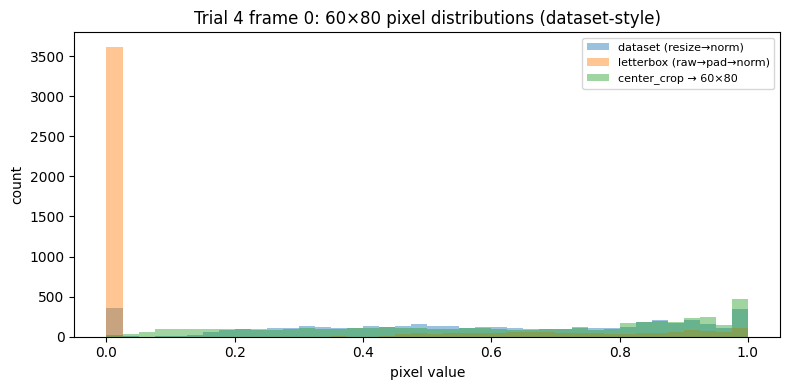

In [65]:
fi = FRAME_INDICES[0]
raw = raw_vid[fi]
print("max |dataset − (normalize then resize)|:", max_abs_diff_wrong_vs_dataset(raw))

fi = FRAME_INDICES[0]
imgs = pipeline_for_display(raw_vid[fi])
fig, ax = plt.subplots(figsize=(8, 4))
for k in list(METHODS.keys()):
    ax.hist(imgs[k].ravel(), bins=40, range=(0, 1), alpha=0.45, label=k)
ax.set_xlabel("pixel value")
ax.set_ylabel("count")
ax.legend(fontsize=8)
ax.set_title(f"Trial {TRIAL_ID} frame {fi}: 60×80 pixel distributions (dataset-style)")
plt.tight_layout()
plt.show()
